In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/fake_job_postings.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFraud distribution:\n{df['fraudulent'].value_counts()}")
print(f"\nFraud percentage: {df['fraudulent'].mean()*100:.2f}%")

Shape: (17880, 18)

Columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Missing values:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Fraud distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Fraud percentage: 4.84%


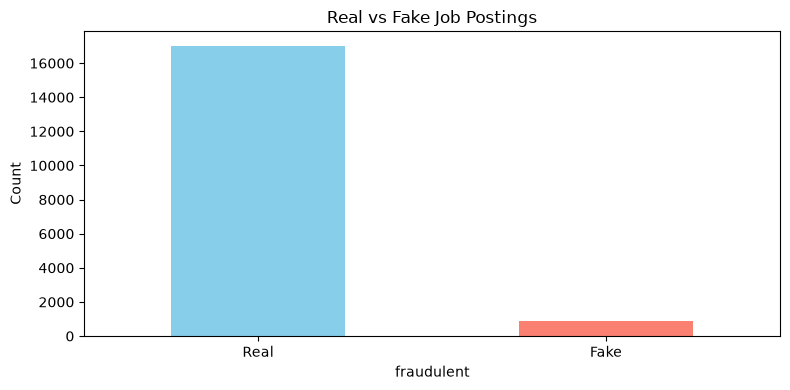

In [2]:
# Cell 2: Fraud distribution
plt.figure(figsize=(8, 4))
df['fraudulent'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Real', 'Fake'], rotation=0)
plt.ylabel('Count')
plt.title('Real vs Fake Job Postings')
plt.tight_layout()
plt.show()

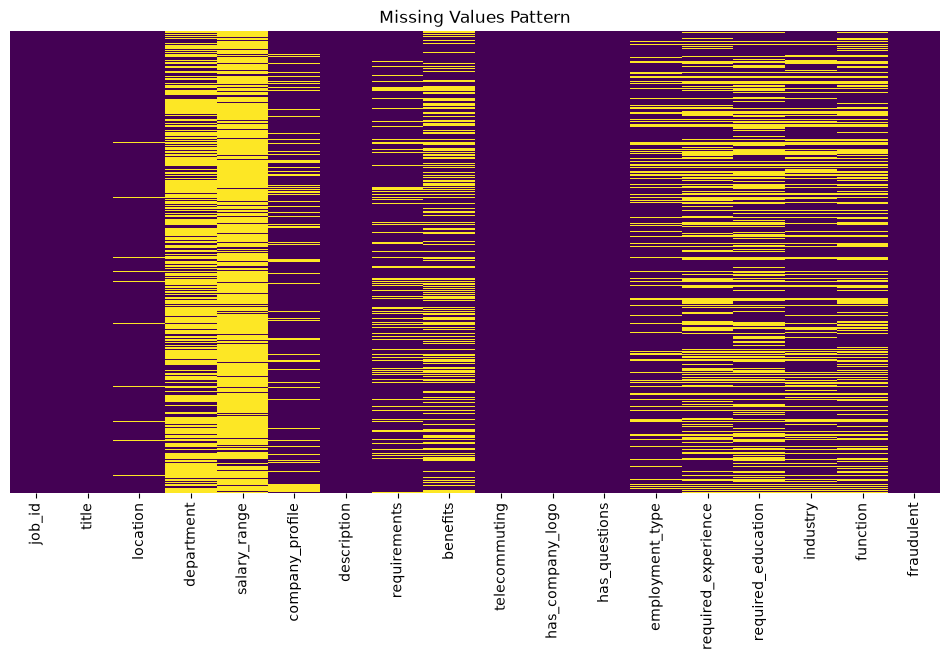

In [3]:
# Cell 3: Missing values heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Pattern')
plt.show()

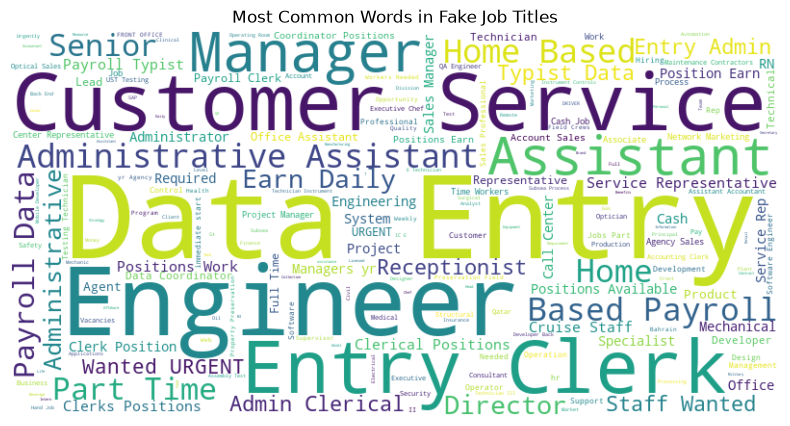

In [4]:
# Cell 4: Word cloud for fake job titles
fake_titles = ' '.join(df[df['fraudulent']==1]['title'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_titles)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Fake Job Titles')
plt.show()

In [7]:
# Cell 5: Save clean data
df_clean = df.copy()
df_clean['description'] = df_clean['description'].fillna('')
df_clean['requirements'] = df_clean['requirements'].fillna('')
df_clean['company_profile'] = df_clean['company_profile'].fillna('')


In [6]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_clean.to_csv('../data/processed/fake_jobs_clean.csv', index=False)
print("Clean data saved")

Clean data saved
